# Diffusion-Limited Heat Treatment in a Slab

This notebook models one-dimensional thermal diffusion in a slab with fixed-temperature boundaries. The heat equation is

$$\partial_t u = -\alpha L u,$$

where $L$ is the positive finite-difference Dirichlet Laplacian. A bounded exponential polynomial approximates the heat propagator $\exp(-\alpha t L)$.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a one-dimensional heat-treatment slab with fixed boundaries.

**QSVT implementation.** It approximates diffusion by an imaginary-time polynomial of the positive Laplacian. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral heat flow validates the cooled temperature profile. The quantum relevance is diffusion or thermal matrix functions on large sparse operators; the notebook uses a small classical grid for validation.


## Variable definitions

- `n_points`: number of interior grid points.
- `length`: slab length.
- `alpha`: thermal diffusivity.
- `time`: diffusion time.
- `x`, `laplacian`: grid coordinates and Dirichlet negative-Laplacian matrix.
- `initial_temperature`: initial slab temperature profile.
- `scaled`: positive-semidefinite rescaling metadata.
- `poly`: imaginary-time polynomial design result.
- `polynomial_heat_operator`: polynomial approximation to the heat operator.
- `exact_heat_operator`: exact spectral heat operator.
- `exact_temperature`, `poly_temperature`: exact and polynomial evolved temperature profiles.
- `relative_error`: relative temperature-profile error.
- `evals`, `scaled_lam`: Laplacian eigenvalues before and after scaling.
- `exact_decay`, `poly_decay`: exact and polynomial damping factors.
- `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.matrix_functions import design_imaginary_time_polynomial
from qsvt.pde import dirichlet_laplacian_1d
from qsvt.polynomials import eval_polynomial
from qsvt.rescaling import rescale_positive_semidefinite
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 48
length = 1.0
alpha = 0.002
time = 0.08
x, laplacian = dirichlet_laplacian_1d(n_points, length=length)

initial_temperature = np.exp(-0.5 * ((x - 0.35) / 0.07) ** 2)
initial_temperature += 0.6 * np.exp(-0.5 * ((x - 0.68) / 0.05) ** 2)

scaled = rescale_positive_semidefinite(laplacian)
poly = design_imaginary_time_polynomial(alpha * time, scaled.scale, degree=24)
polynomial_heat_operator = poly.prefactor * apply_polynomial_to_hermitian(
    scaled.matrix, poly.coeffs
)

exact_heat_operator = apply_function_to_hermitian(
    laplacian, lambda lam: np.exp(-alpha * time * lam)
)

exact_temperature = exact_heat_operator @ initial_temperature
poly_temperature = polynomial_heat_operator @ initial_temperature
relative_error = np.linalg.norm(poly_temperature - exact_temperature) / np.linalg.norm(
    exact_temperature
)
print(f"Relative Error: {relative_error}")

Relative Error: 2.8910082648989737e-15


## Slab geometry

The one-dimensional slab uses fixed-temperature boundaries. Heat diffusion damps high-frequency Laplacian modes over time.


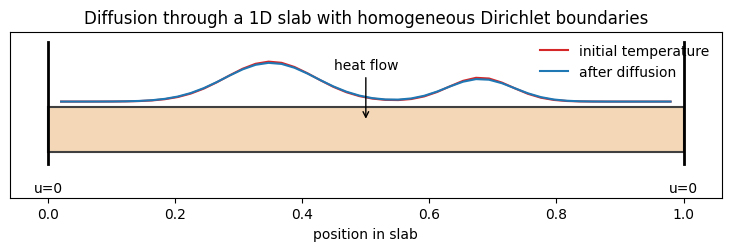

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 2.4), constrained_layout=True)

ax.add_patch(
    plt.Rectangle(
        (0, -0.18), length, 0.36, facecolor="#f3d7b6", edgecolor="0.25", linewidth=1.5
    )
)
ax.plot(
    x,
    0.22 + 0.32 * initial_temperature / np.max(initial_temperature),
    color="tab:red",
    label="initial temperature",
)
ax.plot(
    x,
    0.22 + 0.32 * exact_temperature / np.max(initial_temperature),
    color="tab:blue",
    label="after diffusion",
)
for boundary in [0.0, length]:
    ax.plot([boundary, boundary], [-0.28, 0.70], color="black", linewidth=2.0)
    ax.text(boundary, -0.42, "u=0", ha="center", va="top")
ax.annotate(
    "heat flow",
    xy=(0.5, 0.06),
    xytext=(0.5, 0.48),
    ha="center",
    arrowprops={"arrowstyle": "->"},
)
ax.set_xlabel("position in slab")
ax.set_title("Diffusion through a 1D slab with homogeneous Dirichlet boundaries")
ax.set_xlim(-0.06, length + 0.06)
ax.set_ylim(-0.55, 0.78)
ax.set_yticks([])
ax.legend(loc="upper right", frameon=False)
plt.show()

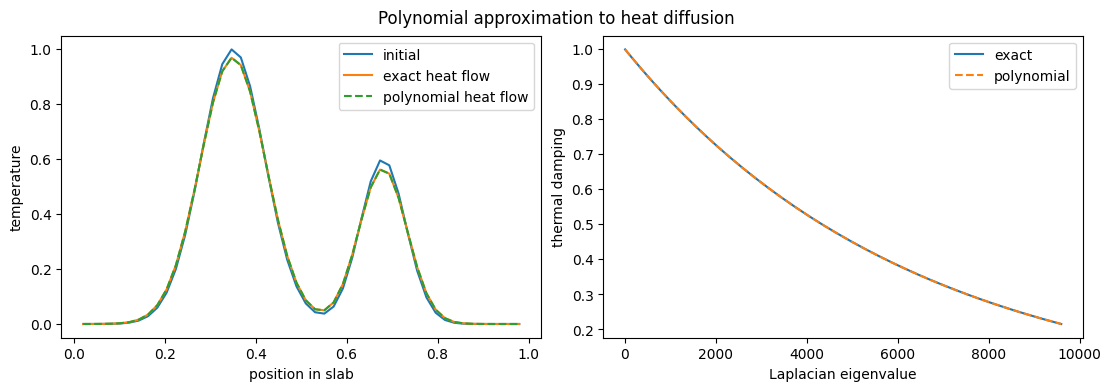

In [4]:
evals, _ = eigh_hermitian(laplacian)
scaled_lam = evals / scaled.scale
exact_decay = np.exp(-alpha * time * evals)
poly_decay = poly.prefactor * eval_polynomial(poly.coeffs, scaled_lam)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(x, initial_temperature, label="initial")
axes[0].plot(x, exact_temperature, label="exact heat flow")
axes[0].plot(x, poly_temperature, "--", label="polynomial heat flow")
axes[0].set_xlabel("position in slab")
axes[0].set_ylabel("temperature")
axes[0].legend()

axes[1].plot(evals, exact_decay, label="exact")
axes[1].plot(evals, poly_decay, "--", label="polynomial")
axes[1].set_xlabel("Laplacian eigenvalue")
axes[1].set_ylabel("thermal damping")
axes[1].legend()

fig.suptitle("Polynomial approximation to heat diffusion")
plt.show()

In [5]:
assert np.linalg.norm(exact_temperature) < np.linalg.norm(initial_temperature)
assert relative_error < 0.03
assert np.max(np.abs(poly_decay - exact_decay)) < 0.03

print(f"relative_temperature_error: {relative_error:.4f}")
print(f"initial_norm [temperature units]: {np.linalg.norm(initial_temperature):.4f}")
print(f"cooled_norm [temperature units]: {np.linalg.norm(exact_temperature):.4f}")
print("validation: passed")

relative_temperature_error: 0.0000
initial_norm [temperature units]: 2.7653
cooled_norm [temperature units]: 2.7152
validation: passed
